# FlowerAura Product — Customer Review Sentiment Analysis

**Objective:** Scrape customer reviews for FlowerAura products, clean and
preprocess the text, run sentiment analysis with TextBlob, and summarize the findings.

**Pipeline**
1. Data Collection (BeautifulSoup + Requests)
2. Data Cleaning & Preprocessing (Pandas + NLTK)
3. Sentiment Analysis (TextBlob)
4. Analysis & Visualization (Pandas, Matplotlib, Seaborn, WordCloud)
5. Reporting

> **Note on scraping:** This notebook uses the exact same scraping logic as the original
> FlowerAura web scraping notebook, collecting Names, Cities, Posted_On, Occasion, Ratings, and Reviews
> from FlowerAura product pages.

In [24]:
# 1. Install / import dependencies
# (Run once; comment out after your environment is set up)
# !pip install beautifulsoup4 requests pandas numpy textblob nltk wordcloud matplotlib seaborn

import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings

import requests
from bs4 import BeautifulSoup

from textblob import TextBlob

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Suppress FutureWarnings from seaborn
warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style="whitegrid")

In [25]:
# 2. FlowerAura Scraping Function (exact logic from original notebook)

def scrape_floweraura_reviews(product_url, max_pages=50):
    """
    Scrape customer reviews from FlowerAura product page.
    This function uses the exact same logic as the original floweraura notebook.
    
    Args:
        product_url (str): Base URL of the FlowerAura product page (without page parameter)
        max_pages (int): Maximum number of pages to scrape
    
    Returns:
        pd.DataFrame: DataFrame containing review data
    """
    Names = []
    Rating = []
    Reviews = []
    Cities = []
    Occasion = []  # Fixed: changed from Occasions to Occasion
    Posted_On = []
    
    try:
        for i in range(1, max_pages + 1):
            cnp = product_url + str(i)
            url_new = cnp
            r = requests.get(url_new)
            
            soup = BeautifulSoup(r.text, "html.parser")
            
            main = soup.find("div", {"class":"review-left-container"})
            
            if not main:
                print(f"No reviews found on page {i}. Stopping scraping.")
                break
                
            sub = main.find_all("div", {"class":"new-review-card-container"})
            
            if not sub:
                print(f"No review cards found on page {i}. Stopping scraping.")
                break
            
            print(f"Scraping page {i}... Found {len(sub)} reviews")
            
            for review_card in sub:
                # Extract name
                name = review_card.find("span", {"class":"review-author-name"})
                Names.append(name.text.title() if name else "Anonymous")
            
                # Extract city and occasion
                city = review_card.find_all("span", {"class":"review-meta-details"})
                Cities.append(city[0].text.title() if len(city) > 0 else "Unknown")
                try:
                    Occasion.append(city[1].text.title() if len(city) > 1 else np.nan)  # Fixed: changed from Occasions to Occasion
                except:
                    Occasion.append(np.nan)  # Fixed: changed from Occasions to Occasion
                    
                # Extract date
                date = review_card.find_all("span")
                try:
                    Posted_On.append(date[4].text if len(date) > 4 else np.nan)
                except:
                    Posted_On.append(np.nan)
            
                # Extract rating
                rating = review_card.find("span", {"class":"star-count-container"})
                Rating.append(rating.text if rating else "0")
            
                # Extract review text
                review = review_card.find_all("div")
                Reviews.append(review[-1].text if review else "")
                
    except Exception as e:
        print(f"Error during scraping: {e}")
    
    # Create DataFrame
    df = pd.DataFrame({
        'Names': Names, 
        'Cities': Cities, 
        'Posted_On': Posted_On, 
        'Occasion': Occasion,  # Fixed: changed from Occasion to Occasion (consistent)
        'Ratings': Rating, 
        'Reviews': Reviews
    })
    
    return df

In [26]:
# 3. Run the scraper with FlowerAura URL
# FlowerAura product URL (10 Red Roses Bouquet) - exact URL from original notebook
FLOWERAURA_URL = "https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page="

# Alternative product URL (Divine Butterscotch Cake) - from original notebook
# FLOWERAURA_URL = "https://www.floweraura.com/reviews/p/10172/divine-butterscotch-cake?page="

# Scrape reviews (adjust max_pages as needed - 10 pages for testing, can go up to 50)
df_raw = scrape_floweraura_reviews(FLOWERAURA_URL, max_pages=10)
df_raw.to_csv("floweraura_reviews_raw.csv", index=False)
print(f"Scraped {len(df_raw)} reviews")
df_raw.shape

Scraping page 1... Found 10 reviews
Scraping page 2... Found 10 reviews
Scraping page 3... Found 10 reviews
Scraping page 4... Found 10 reviews
Scraping page 5... Found 10 reviews
Scraping page 6... Found 10 reviews
Scraping page 7... Found 10 reviews
Scraping page 8... Found 10 reviews
Scraping page 9... Found 10 reviews
Scraping page 10... Found 10 reviews
Scraped 100 reviews


(100, 6)

## 2. Data Cleaning and Preprocessing

In [27]:
# Load raw data (skip re-scraping if you already have the CSV)
df = pd.read_csv("floweraura_reviews_raw.csv")

print("Raw shape:", df.shape)
print(df.isna().sum())

Raw shape: (100, 6)
Names         0
Cities        0
Posted_On     0
Occasion     18
Ratings       0
Reviews       1
dtype: int64


In [28]:
# Drop duplicate reviews
df = df.drop_duplicates(subset=["Names", "Reviews"]).reset_index(drop=True)

# Drop rows with no review text or no rating (core fields for this analysis)
df = df.dropna(subset=["Reviews", "Ratings"]).reset_index(drop=True)

# Clean the Ratings column -> numeric 1-5 (they come as strings from FlowerAura)
df["Ratings"] = pd.to_numeric(df["Ratings"], errors='coerce')
df = df.dropna(subset=["Ratings"]).reset_index(drop=True)
df["Ratings"] = df["Ratings"].astype(int)

# Filter valid ratings (1-5)
df = df[(df["Ratings"] >= 1) & (df["Ratings"] <= 5)].reset_index(drop=True)

print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (99, 6)


,Names,Cities,Posted_On,Occasion,Ratings,Reviews
0,Namitha Felix,Cherthala,Posted On : 4th Sep 2026,Occassion : Birthday,5,Thank you for the prompt delivery. My friend r...
1,Your Love,Pune,Posted On : 6th Jun 2026,Occassion : Valentines Day,5,Fresh flowers were delivered
2,Ramesh Kumar Pariyar,Bengaluru,Posted On : 7th Jan 2026,Occassion : Birthday,5,Great experience with FlowerAura.Delivery was ...
3,Anki M,Shillong,Posted On : 21st Oct 2025,NaN,5,Fresh flowers...liked it.
4,Suraj Chaunal,Noida,Posted On : 23rd Sep 2025,Occassion : Birthday,5,the flowers were fresh and colorful. TBH they ...


In [29]:
# Text preprocessing: lowercase, strip special characters, tokenize,
# remove stopwords, and lemmatize.

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)     # remove punctuation/special chars/numbers
    text = re.sub(r"\s+", " ", text).strip()  # collapse extra whitespace

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

df["Cleaned_Review"] = df["Reviews"].apply(preprocess_text)
df[["Reviews", "Cleaned_Review"]].head()

,Reviews,Cleaned_Review
0,Thank you for the prompt delivery. My friend r...,thank prompt delivery friend really loved itt ...
1,Fresh flowers were delivered,fresh flower delivered
2,Great experience with FlowerAura.Delivery was ...,great experience floweraura delivery time prod...
3,Fresh flowers...liked it.,fresh flower liked
4,the flowers were fresh and colorful. TBH they ...,flower fresh colorful tbh better expected thanks


## 3. Sentiment Analysis (TextBlob)

In [30]:
def get_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    label = "Positive" if polarity >= 0.1 else "Negative"
    return pd.Series([polarity, subjectivity, label])

df[["Polarity", "Subjectivity", "Sentiment"]] = df["Cleaned_Review"].apply(get_sentiment)
df.head()

,Names,Cities,Posted_On,Occasion,Ratings,Reviews,Cleaned_Review,Polarity,Subjectivity,Sentiment
0,Namitha Felix,Cherthala,Posted On : 4th Sep 2026,Occassion : Birthday,5,Thank you for the prompt delivery. My friend r...,thank prompt delivery friend really loved itt ...,0.600000,0.933333,Positive
1,Your Love,Pune,Posted On : 6th Jun 2026,Occassion : Valentines Day,5,Fresh flowers were delivered,fresh flower delivered,0.300000,0.500000,Positive
2,Ramesh Kumar Pariyar,Bengaluru,Posted On : 7th Jan 2026,Occassion : Birthday,5,Great experience with FlowerAura.Delivery was ...,great experience floweraura delivery time prod...,0.585714,0.773810,Positive
3,Anki M,Shillong,Posted On : 21st Oct 2025,NaN,5,Fresh flowers...liked it.,fresh flower liked,0.450000,0.650000,Positive
4,Suraj Chaunal,Noida,Posted On : 23rd Sep 2025,Occassion : Birthday,5,the flowers were fresh and colorful. TBH they ...,flower fresh colorful tbh better expected thanks,0.240000,0.400000,Positive


# Sentiment distribution
sentiment_counts = df["Sentiment"].value_counts()
print(sentiment_counts)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Sentiment", hue="Sentiment", order=["Positive", "Negative"], palette="Set2", legend=False)
plt.title("Overall Sentiment Distribution — FlowerAura Product Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

   Ratings  Polarity
0        3  0.500000
1        4  0.514286
2        5  0.514400


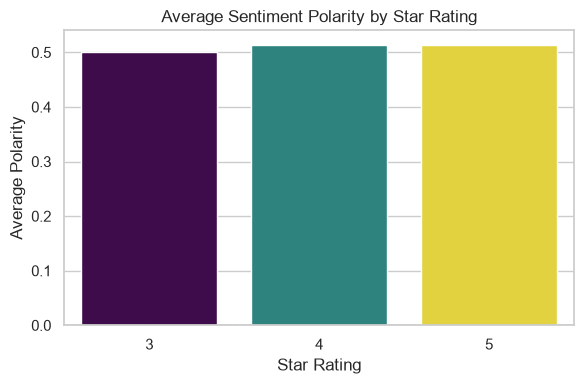

In [31]:
# Average rating vs sentiment polarity
rating_sentiment = df.groupby("Ratings")["Polarity"].mean().reset_index()
print(rating_sentiment)

plt.figure(figsize=(6, 4))
sns.barplot(data=rating_sentiment, x="Ratings", y="Polarity", hue="Ratings", palette="viridis", legend=False)
plt.title("Average Sentiment Polarity by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Average Polarity")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

   Ratings  Polarity
0        3  0.500000
1        4  0.514286
2        5  0.514400


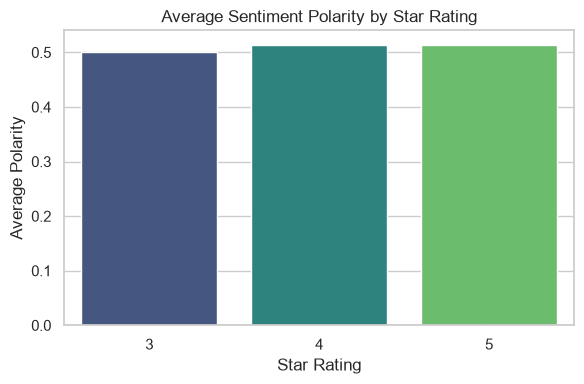

In [32]:
# Average rating vs sentiment polarity
rating_sentiment = df.groupby("Ratings")["Polarity"].mean().reset_index()
print(rating_sentiment)

plt.figure(figsize=(6, 4))
sns.barplot(data=rating_sentiment, x="Ratings", y="Polarity", palette="viridis")
plt.title("Average Sentiment Polarity by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Average Polarity")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

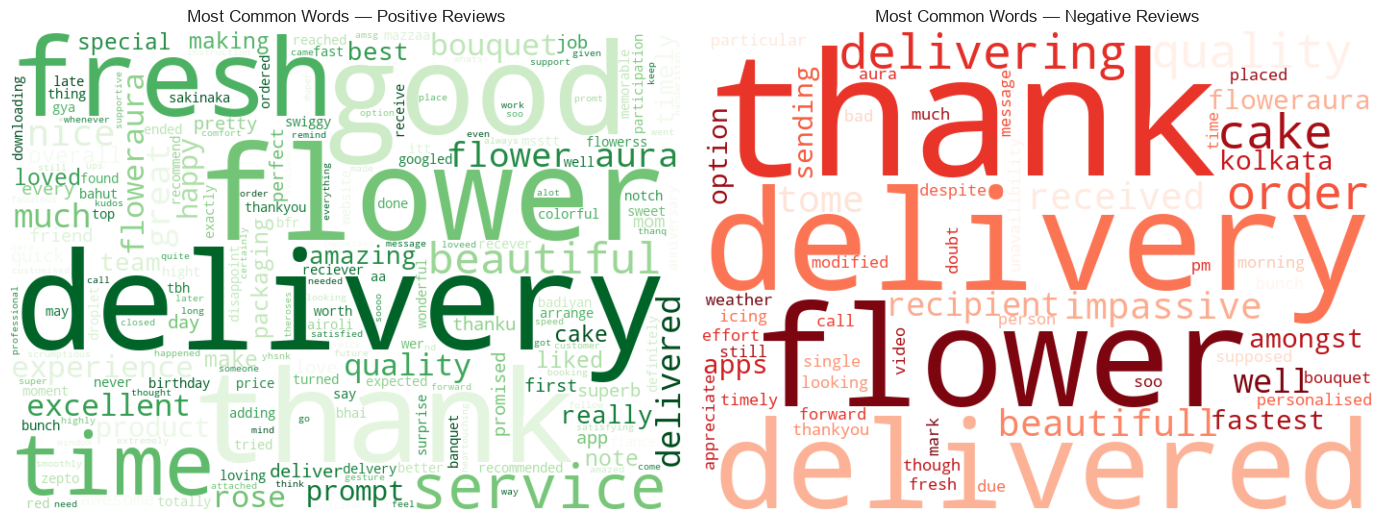

In [33]:
# Word clouds for positive and negative reviews
positive_text = " ".join(df.loc[df["Sentiment"] == "Positive", "Cleaned_Review"])
negative_text = " ".join(df.loc[df["Sentiment"] == "Negative", "Cleaned_Review"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if positive_text.strip():
    wc_pos = WordCloud(width=700, height=500, background_color="white", colormap="Greens").generate(positive_text)
    axes[0].imshow(wc_pos, interpolation="bilinear")
axes[0].set_title("Most Common Words — Positive Reviews")
axes[0].axis("off")

if negative_text.strip():
    wc_neg = WordCloud(width=700, height=500, background_color="white", colormap="Reds").generate(negative_text)
    axes[1].imshow(wc_neg, interpolation="bilinear")
axes[1].set_title("Most Common Words — Negative Reviews")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [34]:
# Save the final, enriched dataset
df.to_csv("floweraura_reviews_analyzed.csv", index=False)
df.head()

,Names,Cities,Posted_On,Occasion,Ratings,Reviews,Cleaned_Review,Polarity,Subjectivity,Sentiment
0,Namitha Felix,Cherthala,Posted On : 4th Sep 2026,Occassion : Birthday,5,Thank you for the prompt delivery. My friend r...,thank prompt delivery friend really loved itt ...,0.600000,0.933333,Positive
1,Your Love,Pune,Posted On : 6th Jun 2026,Occassion : Valentines Day,5,Fresh flowers were delivered,fresh flower delivered,0.300000,0.500000,Positive
2,Ramesh Kumar Pariyar,Bengaluru,Posted On : 7th Jan 2026,Occassion : Birthday,5,Great experience with FlowerAura.Delivery was ...,great experience floweraura delivery time prod...,0.585714,0.773810,Positive
3,Anki M,Shillong,Posted On : 21st Oct 2025,NaN,5,Fresh flowers...liked it.,fresh flower liked,0.450000,0.650000,Positive
4,Suraj Chaunal,Noida,Posted On : 23rd Sep 2025,Occassion : Birthday,5,the flowers were fresh and colorful. TBH they ...,flower fresh colorful tbh better expected thanks,0.240000,0.400000,Positive


## 5. Reporting

Fill this section in once the notebook has been run end-to-end on live data.

**Overview**
- Number of reviews collected: `len(df)` after cleaning and deduplication.
- Data collected via BeautifulSoup + Requests from FlowerAura website.

**Sentiment Analysis Results**
- Positive vs. negative split: see the countplot above (`sentiment_counts`).
- Average polarity per star rating: see `rating_sentiment` — check whether polarity
  rises monotonically with rating, or whether some low/high ratings buck the trend.

**Insights**
- Inspect the word clouds for recurring themes (e.g. flower freshness, delivery timeliness,
  packaging, arrangement quality) in both positive and negative reviews.
- Compare review length between sentiment classes — do negative reviews tend to be
  longer (more detailed complaints) than positive ones, or vice versa?

**Recommendations**
- Summarize 2–3 concrete product or marketing takeaways based on the most frequent
  negative themes (e.g. if "delivery" appears often in negative reviews, flag delivery
  timeliness as a focus area).
- Note any mismatch between star ratings and text sentiment (e.g. 5-star reviews with
  mixed-sentiment text), which can indicate reviewers who rate highly but mention specific
  issues in their text.